# 1 · Tutorial — one vessel image, explained end to end

This is the place to start. We take a single Mulga (*Acacia aneura*) cross-section,
`GUNDA_ACC_T4_1_10x.png`, and walk it through every stage of the
`vessel_morphometry` package:

1. the **(green − red)** channel that makes vessels pop,
2. the **Otsu mask** that turns brightness into yes/no-vessel,
3. the **colour-coded label overlay** (each vessel a different colour),
4. the **labelled PNG** the package writes (outlines + id numbers),
5. the **metrics table** (one row per vessel), and
6. the **SVG** — an editable vector tracing of every vessel.

Then two *under-the-hood* sections open up ideas the package hides:

- **(a)** how *connected-component labelling* actually works, and why a naive
  hand-rolled version is `O(N²)` while `skimage` is `O(N)`;
- **(b)** how the choice of *perimeter* changes **circularity** by ~38%.

In [1]:
# Run from the repo root so that data/ and outputs/ resolve the same way whether
# you launched Jupyter inside notebooks/ or at the top of the repo.
import os
from pathlib import Path

if not Path("data/10x").exists() and Path("../data/10x").exists():
    os.chdir("..")
print("working directory:", Path.cwd())

working directory: C:\Users\metas\repos\vessel_analysis


In [2]:
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, display

import vessel_morphometry as vm

%matplotlib inline

IMG = "data/10x/GUNDA_ACC_T4_1_10x.png"


def show(img_rgb, title="", cmap=None):
    # Display an image inline with no axes.
    plt.figure(figsize=(9, 7))
    plt.imshow(img_rgb, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Step 0 · The raw image

OpenCV loads images in **BGR** order, so we flip to RGB just for display. The
vessels are the bright **cyan** holes; the surrounding **magenta** is cell-wall
tissue.

image shape: (768, 1024, 3)


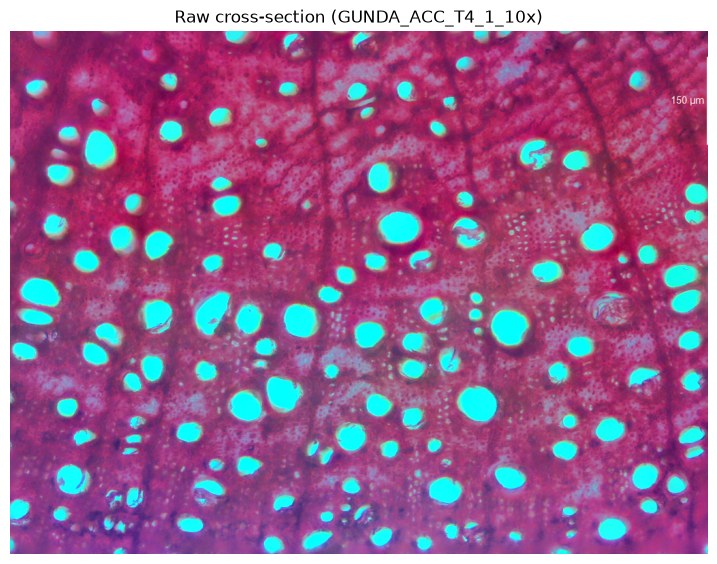

In [3]:
img = cv2.imread(IMG)                       # BGR, shape (H, W, 3)
print("image shape:", img.shape)
show(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "Raw cross-section (GUNDA_ACC_T4_1_10x)")

## Step 1 · The (green − red) channel

The whole detector is one subtraction. The cyan stain is high in **green** (and
blue); the magenta tissue is high in **red** (and blue). Blue is high in *both*,
so the old blue-channel threshold couldn't cleanly separate them. But on the
`green − red` axis the two stains sit at opposite ends, so a single subtraction
lights up the vessels and darkens the tissue.

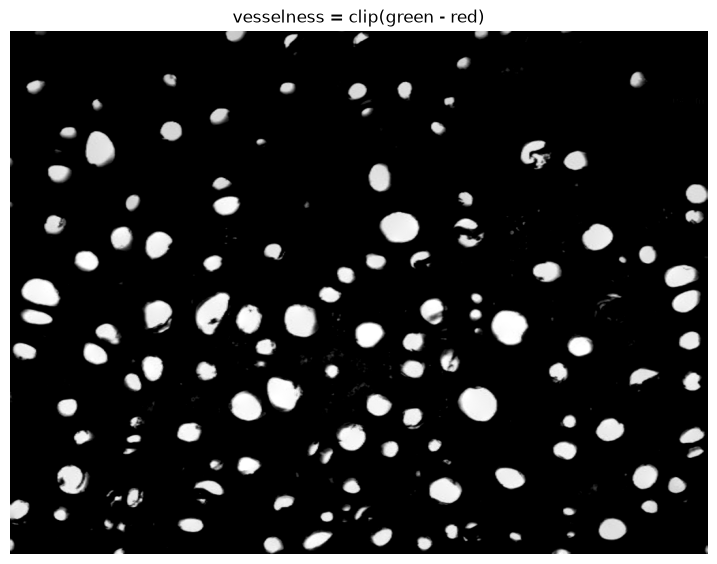

In [4]:
v = vm.vesselness(img)                       # uint8: vessels bright, tissue dark
show(v, "vesselness = clip(green - red)", cmap="gray")

## Step 2 · The Otsu mask

`green − red` is still a greyscale image — we need a yes/no decision per pixel.
**Otsu's method** picks the threshold that best splits the histogram into two
groups automatically, so there is no magic number to tune. (The package then
does a tiny morphological *opening* to drop speckle and fills lumen holes; here
we show the raw threshold so you can see what Otsu chose.)

Otsu threshold: 110  | vessel pixels: 75157


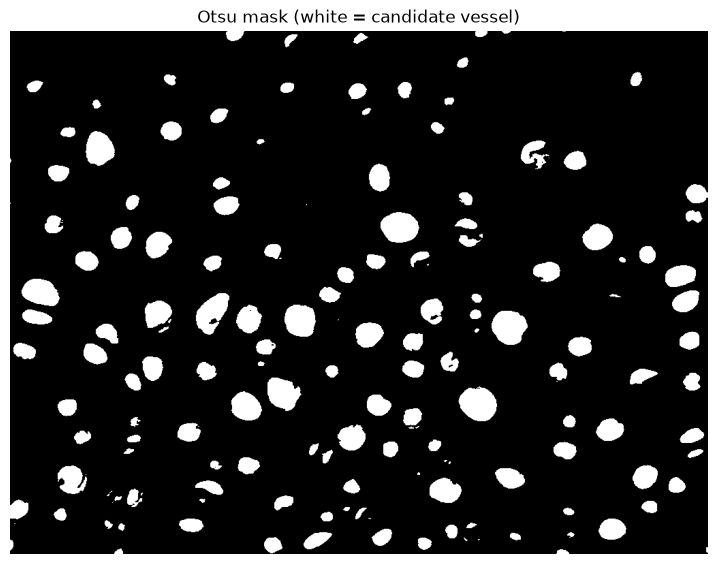

In [5]:
from skimage.filters import threshold_otsu

t = threshold_otsu(v)
mask = v > t
print("Otsu threshold:", t, " | vessel pixels:", int(mask.sum()))
show(mask, "Otsu mask (white = candidate vessel)", cmap="gray")

## Step 3 · Label image → colour-coded overlay

`vm.segment` runs the mask through cleanup, **connected-component labelling**
(each separate blob gets its own integer id), and an area filter that drops
specks and implausibly large blobs. We colour each label differently and lay it
over the original image — a quick visual check that the segmentation found real,
separated vessels.

vessels found: 137


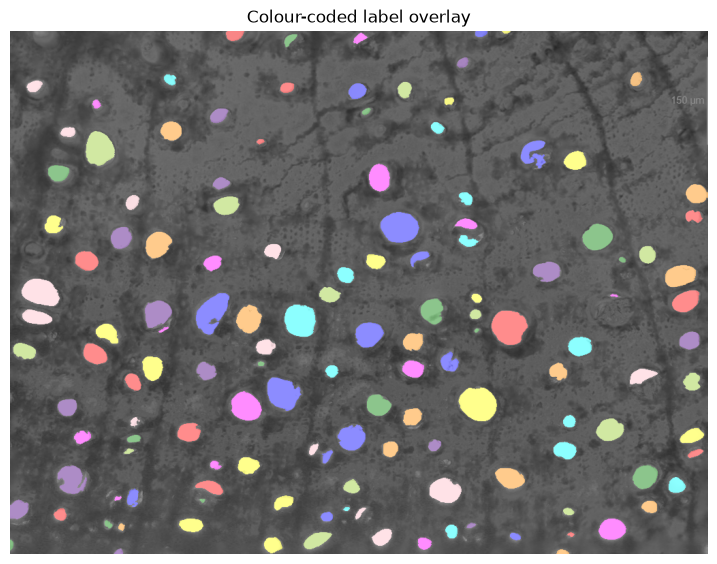

In [6]:
from skimage.color import label2rgb

labels = vm.segment(img)                     # 0 = background, 1..N = vessels
print("vessels found:", int(labels.max()))

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = label2rgb(labels, image=rgb, alpha=0.45, bg_label=0)
show(overlay, "Colour-coded label overlay")

## Step 4 · Run the whole pipeline

`vm.run` does all of the above and also **measures** every vessel and **writes**
four files into `outputs/`: the metrics CSV, a labelled PNG, a QC overlay, and an
editable SVG. It returns the metrics table and the vessel area fraction.

In [7]:
df, fraction = vm.run(IMG, out_dir="outputs")

stem = Path(IMG).stem
print("rows (vessels):", len(df))
print("vessel area fraction:", round(fraction["vessel_fraction"], 4),
      "(=", fraction["vessel_px"], "vessel px /", fraction["image_px"], "image px)")
sorted(p.name for p in Path("outputs").glob(stem + "*"))

rows (vessels): 137
vessel area fraction: 0.095 (= 74713 vessel px / 786432 image px)


['GUNDA_ACC_T4_1_10x_labelled.png',
 'GUNDA_ACC_T4_1_10x_overlay.png',
 'GUNDA_ACC_T4_1_10x_vessels.csv',
 'GUNDA_ACC_T4_1_10x_vessels.svg']

## Step 5 · The labelled PNG

The package draws each vessel outline in yellow and prints its id at the
centroid, so you can match a row in the table to a vessel on the slide.

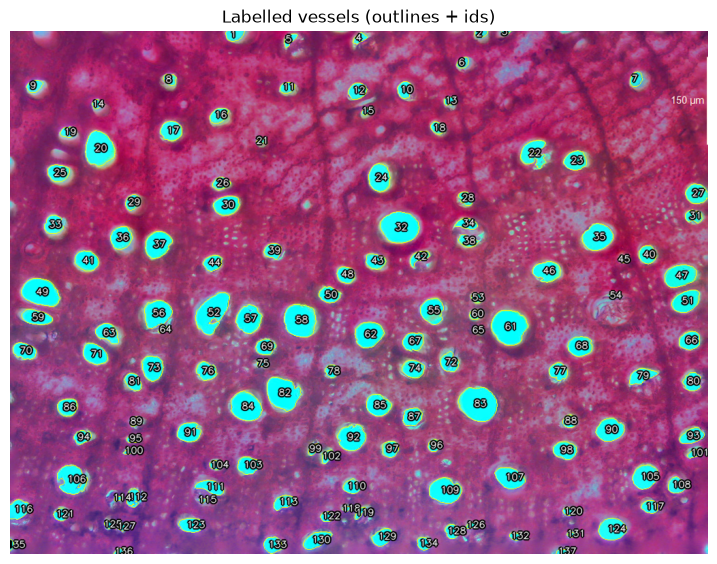

In [8]:
labelled = plt.imread("outputs/" + stem + "_labelled.png")
show(labelled, "Labelled vessels (outlines + ids)")

## Step 6 · The metrics table

One row per vessel. Lengths are in **pixels** (`area_um2` is `NaN` until you set
the calibration in `config.py`). See the README for what each column means.

In [9]:
cols = ["vessel_id", "area_px", "circularity", "diam_major_px", "diam_minor_px",
        "aspect_ratio", "eccentricity", "solidity", "touches_border"]
df[cols].head(10)

,vessel_id,area_px,circularity,diam_major_px,diam_minor_px,aspect_ratio,eccentricity,solidity,touches_border
0,1,317.0,0.821382,27.081418,15.560900,0.574597,0.818437,0.963526,True
1,2,139.0,0.838500,19.186414,9.467753,0.493461,0.869768,0.978873,True
2,3,39.0,0.634544,12.334784,4.261704,0.345503,0.938418,0.975000,True
3,4,188.0,0.792286,21.115500,11.877308,0.562492,0.826802,0.935323,False
4,5,195.0,0.724217,24.113819,11.088036,0.459821,0.888012,0.919811,False
5,6,187.0,0.935321,18.364554,13.051110,0.710668,0.703527,0.954082,False
6,7,267.0,0.913039,21.702463,15.716562,0.724183,0.689608,0.950178,False
7,8,215.0,0.877538,18.956677,14.873010,0.784579,0.620029,0.934783,False
8,9,288.0,0.903180,23.684293,15.629044,0.659891,0.751362,0.956811,False
9,10,377.0,0.957772,24.376144,19.856549,0.814589,0.580038,0.959288,False


## Step 7 · The SVG — an editable vector tracing

The SVG embeds the original image and draws one **editable polygon** per vessel
on top, plus its id. Because it is vector, you can open it in a browser, Inkscape
or Illustrator, recolour outlines, nudge a vertex, or pull the polygons out — it
is the automated stand-in for hand-tracing the vessels, which is what this whole
pipeline replaced.

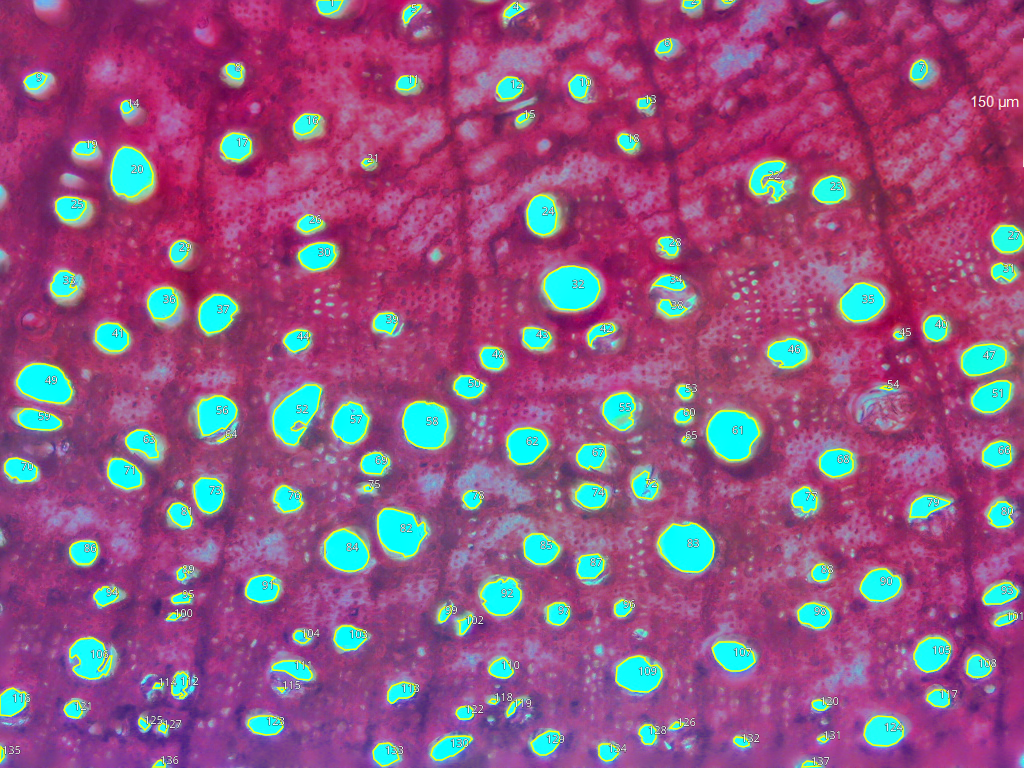

In [10]:
display(SVG(filename="outputs/" + stem + "_vessels.svg"))

---
# Under the hood (a) · Connected components

Steps 3–4 quietly turned a *mask* (a sea of `True`/`False` pixels) into
*numbered objects*. That step is **connected-component labelling**: find each
group of touching foreground pixels and give it one id.

### The legacy idea: hand-rolled flood fill

The original notebooks grew each blob by hand. Start from a bright pixel, look at
its 4 neighbours, keep the ones that are also bright, and repeat — a *flood
fill*. The catch was **how they checked "is this pixel part of the foreground?"**:
they scanned a Python list of every foreground coordinate, every single time.
A scan is `O(N)`, and it happens for `O(N)` pixels, so the whole thing is
`O(N²)`. Below is that idea, kept faithful to the slow part.

In [11]:
def legacy_flood_fill(mask):
    # Hand-rolled labelling, like the original notebook. The deliberately slow
    # part is `nb in coord_list`: a linear scan of every foreground coordinate
    # on every step. That linear scan is what makes the whole thing O(N^2).
    coords = [tuple(p) for p in np.argwhere(mask)]
    coord_list = list(coords)          # membership tested by O(N) list scan
    remaining = set(coords)
    out = np.zeros(mask.shape, dtype=int)
    current = 0
    while remaining:
        seed = next(iter(remaining))
        current += 1
        stack = [seed]
        remaining.discard(seed)
        while stack:
            i, j = stack.pop()
            out[i, j] = current
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nb = (i + di, j + dj)
                if nb in coord_list and nb in remaining:   # <-- the O(N) scan
                    remaining.discard(nb)
                    stack.append(nb)
    return out, current

### `skimage.measure.label`: the fast way

`skimage` does the same job with a two-pass union-find algorithm written in C.
It touches each pixel a constant number of times, so it is `O(N)` — and the
constant is tiny because it is compiled. We call it with `connectivity=1` so it
uses the same 4-neighbour rule as our flood fill, then time both on increasingly
large windows cut from the **centre** of our mask (so each window actually
contains tissue), and watch the two curves diverge.

In [12]:
from skimage.measure import label as sk_label

H, W = mask.shape
ci, cj = H // 2, W // 2          # centre of the image (tissue-rich)

records = []
for size in [60, 90, 120, 150, 180, 220]:
    h = size // 2
    crop = mask[ci - h:ci + h, cj - h:cj + h]
    n_fg = int(crop.sum())

    start = time.perf_counter()
    legacy_flood_fill(crop)
    legacy_ms = 1000 * (time.perf_counter() - start)

    start = time.perf_counter()
    sk_label(crop, connectivity=1)       # connectivity=1 = 4-neighbours, matching the flood fill
    skimage_ms = 1000 * (time.perf_counter() - start)

    records.append({"window": f"{size}x{size}", "fg_pixels": n_fg,
                    "legacy_ms": legacy_ms, "skimage_ms": skimage_ms})

timing = pd.DataFrame(records)
timing

,window,fg_pixels,legacy_ms,skimage_ms
0,60x60,341,6.0106,0.1304
1,90x90,981,38.5149,0.1171
2,120x120,1973,148.1201,0.1714
3,150x150,3038,340.7191,0.1990
4,180x180,5099,980.3375,0.2377
5,220x220,7847,2273.8651,0.2808


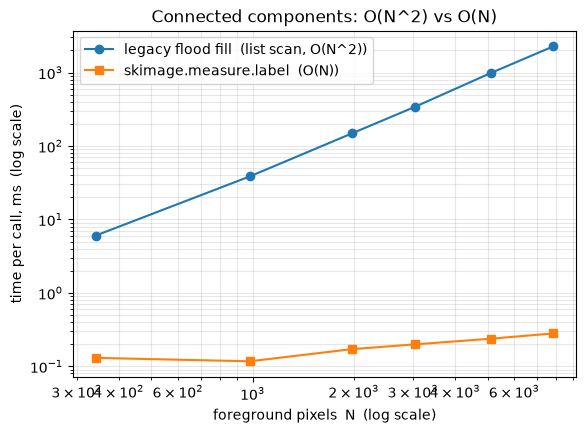

At the largest window the hand-rolled version is ~8,098x slower.


In [13]:
# On a log-log plot, a straight line of slope ~2 means O(N^2); flat means O(N).
plt.figure(figsize=(6.5, 4.5))
plt.loglog(timing.fg_pixels, timing.legacy_ms, "o-", label="legacy flood fill  (list scan, O(N^2))")
plt.loglog(timing.fg_pixels, timing.skimage_ms, "s-", label="skimage.measure.label  (O(N))")
plt.xlabel("foreground pixels  N  (log scale)")
plt.ylabel("time per call, ms  (log scale)")
plt.title("Connected components: O(N^2) vs O(N)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

slowdown = timing.legacy_ms.iloc[-1] / timing.skimage_ms.iloc[-1]
print(f"At the largest window the hand-rolled version is ~{slowdown:,.0f}x slower.")

**Why the gap explodes.** Double the number of foreground pixels `N`: the legacy
version does ~2× more flood-fill steps **and** each membership scan is ~2×
longer, so the cost rises ~4× — the upward bend you see on the log-log plot.
`skimage` stays flat: doubling `N` just doubles a cheap, constant amount of work
per pixel. The fix was never a faster computer — it was the right data structure
(an array/union-find lookup instead of a linear list scan).

---
# Under the hood (b) · Perimeter & circularity

**Circularity** is `4·π·A / P²` — it is `1.0` for a perfect circle and smaller
for ragged shapes. The area `A` is unambiguous (count the pixels). The
**perimeter `P` is not**, and the original pipeline got it wrong.

### Two ways to measure a perimeter

- **Staircase** (the legacy way): walk the outline and count the *exposed pixel
  edges*. Every boundary pixel contributes the little vertical/horizontal steps
  of a staircase. For a smooth, slanted curve this **over-measures** the true
  length by about `4/π ≈ 1.27`.
- **Crofton** (what the package uses): estimate the boundary length from how
  often lines at several angles cross it. This is close to unbiased for smooth
  shapes.

Let's compute the staircase perimeter ourselves on the *same* vessels and
compare the resulting circularity to the package's Crofton value.

In [14]:
def staircase_perimeter_per_label(labels):
    # Total exposed 4-connected pixel edges for every label id. For each
    # foreground pixel, count how many of its 4 neighbours are NOT the same
    # label (background, a different vessel, or off the image). Summed per
    # label, that is the staircase perimeter.
    padded = np.pad(labels, 1, mode="constant", constant_values=-1)
    inner = padded[1:-1, 1:-1]
    edges = np.zeros(labels.shape, dtype=np.int64)
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        neighbour = padded[1 + di:1 + di + labels.shape[0],
                           1 + dj:1 + dj + labels.shape[1]]
        edges += (neighbour != inner)
    return np.bincount(labels.ravel(), weights=edges.ravel())   # indexed by label id

In [15]:
# Match each table row (vessel_id) to its area and staircase perimeter.
per_staircase = staircase_perimeter_per_label(labels)
area_by_label = np.bincount(labels.ravel()).astype(float)

ids = df["vessel_id"].astype(int).values
A = area_by_label[ids]
P = per_staircase[ids]
circ_staircase = 4 * np.pi * A / np.where(P == 0, np.nan, P) ** 2

compare = pd.DataFrame({
    "vessel_id": ids,
    "circularity_crofton": df["circularity"].values,    # from the package
    "circularity_staircase": circ_staircase,
})
compare.head(10)

,vessel_id,circularity_crofton,circularity_staircase
0,1,0.821382,0.564561
1,2,0.838500,0.599014
2,3,0.634544,0.423952
3,4,0.792286,0.431424
4,5,0.724217,0.424246
5,6,0.935321,0.573709
6,7,0.913039,0.551483
7,8,0.877538,0.521175
8,9,0.903180,0.538238
9,10,0.957772,0.584879


In [16]:
med_crofton = compare["circularity_crofton"].median()
med_staircase = compare["circularity_staircase"].median()
print(f"median circularity, Crofton   : {med_crofton:.3f}")
print(f"median circularity, staircase : {med_staircase:.3f}")
print(f"ratio (staircase / Crofton)   : {med_staircase / med_crofton:.3f}")
print(f"(pi/4)^2                       : {(np.pi/4)**2:.3f}   <- the predicted gap")

median circularity, Crofton   : 0.907
median circularity, staircase : 0.552
ratio (staircase / Crofton)   : 0.609
(pi/4)^2                       : 0.617   <- the predicted gap


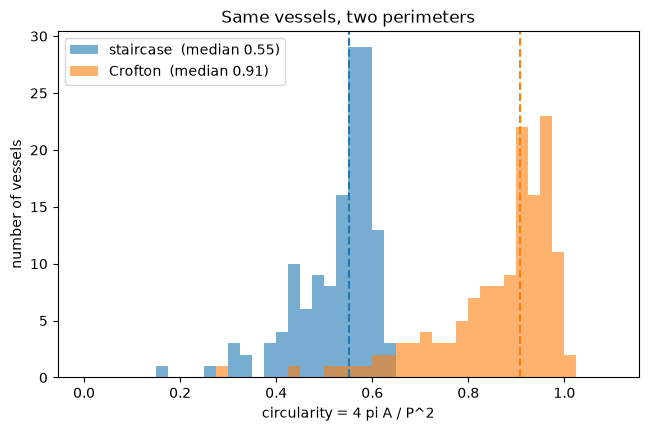

In [17]:
plt.figure(figsize=(7.5, 4.5))
bins = np.linspace(0, 1.1, 45)
plt.hist(compare["circularity_staircase"], bins=bins, alpha=0.6,
         label=f"staircase  (median {med_staircase:.2f})")
plt.hist(compare["circularity_crofton"], bins=bins, alpha=0.6,
         label=f"Crofton  (median {med_crofton:.2f})")
plt.axvline(med_staircase, color="C0", ls="--")
plt.axvline(med_crofton, color="C1", ls="--")
plt.xlabel("circularity = 4 pi A / P^2")
plt.ylabel("number of vessels")
plt.title("Same vessels, two perimeters")
plt.legend()
plt.show()

### Why the medians differ by ~38%

The staircase over-measures the perimeter by a factor of about `4/π`. Circularity
divides by `P²`, so the staircase circularity is smaller by about

$$\left(\frac{\pi}{4}\right)^2 \approx 0.62.$$

That single factor explains almost the entire jump you just saw — from a median
near **0.55** (staircase) up to **~0.91** (Crofton). The vessels did not change
shape; only the ruler did. The original pipeline reported the lower, biased
numbers; correcting the perimeter raises the median circularity by ~38%.